# NB00 — Data Audit: `~/data/CrohnsPhage/` + Compositional-DA Proof of Concept

**Project**: `ibd_phage_targeting`
**Environment**: local — no Spark. Operates purely on the CrohnsPhage parquet mart.

## Purpose

Three deliverables:

1. **Profile every parquet** in `~/data/CrohnsPhage/` and validate against the committed per-table data dictionary YAMLs + `schema_overview.yaml`. Flag any drift.
2. **Commit `data/table_schemas.md`** — a concise, readable schema for the CrohnsPhage fact / ref tables (since `docs/schemas/` has no coverage for this project-local mart).
3. **Compositional-DA proof of concept** — reproduce a slice of the preliminary Mann-Whitney DA on relative abundance, run a compositional-aware (CLR-based) alternative on the same slice, and compare the two on a battery of canonical protective species (*C. scindens*, *F. prausnitzii*, *A. muciniphila*, *R. intestinalis*, *R. hominis*, *L. eligens*). This directly tests the norm-N1 motivating claim that pre-computed DA needs verification and establishes whether compositional-aware re-analysis will change conclusions.

This notebook does *not* do ecotype stratification — that's NB01. NB00's DA runs are pooled, identical to the preliminary pipeline, but adding the compositional-aware comparator.


In [1]:
import yaml
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

DATA_MART = Path.home() / 'data' / 'CrohnsPhage'
DATA_OUT  = Path('../data')
FIG_OUT   = Path('../figures')
DATA_OUT.mkdir(parents=True, exist_ok=True)
FIG_OUT.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_rows', 80)
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 200)


## 1. Load lineage and schema overview

In [2]:
with open(DATA_MART / 'lineage.yaml') as f:
    lineage = yaml.safe_load(f)
with open(DATA_MART / 'schema_overview.yaml') as f:
    schema_overview = yaml.safe_load(f)

print(f"Schema version: {lineage['schema_version']}")
print(f"ETL date: {lineage['etl_date']}")
print(f"ETL version: {lineage['etl_version']}")
print(f"Active tables: {lineage['active_tables']}")
print(f"Superseded tables: {schema_overview['superseded_tables']}")
print()
print(f"Dimension tables: {len(schema_overview['dimension_tables'])}")
print(f"Fact tables:      {len(schema_overview['fact_tables'])}")
print(f"Reference tables: {len(schema_overview['reference_tables'])}")
print()
print('Known data gaps (lineage.yaml):')
for gap in lineage['known_data_gaps']:
    print(f'  - {gap}')


Schema version: LAKEHOUSE_SCHEMA_v2.md (v2.4)
ETL date: 2026-03-28
ETL version: v10 (serology cleanup)
Active tables: 33
Superseded tables: ['ref_franzosa_hmp2_mzrt_bridge', 'ref_franzosa_metabolomics', 'ref_franzosa_sample_metadata', 'ref_kumbhari_sample_metadata']

Dimension tables: 4
Fact tables:      8
Reference tables: 21

Known data gaps (lineage.yaml):
  - Dave lab clinical metadata (HBI/CDAI for ~23 patients) — need from Dave lab
  - Dave lab pipeline documentation — 16S pipeline, reference DB, versions unknown
  - HMP2 EC enzyme profiles (108K ECs x 1,638 samples) — on disk, not yet in schema
  - C18n_Metabolites_ID_AfterPublication_2021-05-17.xlsx — 62 additional metabolite IDs not yet integrated
  - PRISM MetaPhlAn3 profiles — would require SRA download + reprocessing
  - Kumbhari samples not in fact_clinical (5,492 of 6,138) lack dim_samples entries
  - Viral taxonomy reconciliation incomplete — only 19/316 VirMAP taxa in dim_taxa


## 2. Profile every parquet and reconcile against dictionary YAMLs

In [3]:
def profile_parquet(path):
    """Load a parquet and return shape + per-column dtype, null count, unique count."""
    df = pd.read_parquet(path)
    cols = []
    for c in df.columns:
        nun = df[c].nunique(dropna=True)
        cols.append({
            'column': c,
            'dtype': str(df[c].dtype),
            'n_null': int(df[c].isna().sum()),
            'n_unique': int(nun),
            'pct_null': float(df[c].isna().mean()),
        })
    return {
        'rows': len(df),
        'n_columns': df.shape[1],
        'size_mb': path.stat().st_size / 1024**2,
        'columns': cols,
    }

all_files = sorted(DATA_MART.glob('*.snappy.parquet'))
print(f'Found {len(all_files)} parquet files')

profiles = {}
for p in all_files:
    name = p.name.replace('.snappy.parquet', '')
    profiles[name] = profile_parquet(p)
    profiles[name]['path'] = str(p)

# Summary of sizes
rows = []
for name, prof in profiles.items():
    rows.append({'table': name, 'rows': prof['rows'], 'cols': prof['n_columns'], 'size_mb': prof['size_mb']})
summary = pd.DataFrame(rows).sort_values('rows', ascending=False).reset_index(drop=True)
summary


Found 33 parquet files


,table,rows,cols,size_mb
0,fact_metabolomics,30214762,5,152.109904
1,fact_pathway_abundance,6992284,6,64.999593
2,fact_taxon_abundance,695105,9,5.235278
3,ref_strain_trait_associations,356157,7,7.703749
4,ref_kumbhari_s7_gene_strain_inference,219121,11,9.967118
5,ref_kumbhari_s7_uhgp90_foldseek_cluster_m,176457,7,2.959680
6,ref_hmp2_metabolite_annotations,81867,7,2.002503
7,ref_kumbhari_s7_eggerthella_lenta_predict,68503,8,2.512296
8,fact_strain_competition,15520,14,0.627892
9,dim_samples,10774,24,0.217851


In [4]:
# Load dictionary YAMLs (one per table)
DICT_DIR = DATA_MART / 'data_dictionary'
dict_files = sorted(DICT_DIR.glob('*.yaml'))
print(f'Found {len(dict_files)} dictionary YAMLs')

dictionaries = {}
for dp in dict_files:
    with open(dp) as f:
        dictionaries[dp.stem] = yaml.safe_load(f)
print(f'Dictionary coverage: {sorted(dictionaries.keys())[:5]} ...')


Found 33 dictionary YAMLs


Dictionary coverage: ['dim_participants', 'dim_samples', 'dim_studies', 'dim_taxa', 'fact_clinical_longitudinal'] ...


In [5]:
# Reconcile lineage.yaml row counts vs actual parquet row counts
def _lineage_rows(name):
    t = lineage.get('tables', {}).get(name, {})
    if 'rows' in t: return t['rows']
    return None

reconcile_rows = []
for name in sorted(profiles.keys()):
    actual = profiles[name]['rows']
    expected = _lineage_rows(name)
    if expected is None:
        status = 'NOT_IN_LINEAGE'
    elif actual == expected:
        status = 'OK'
    else:
        status = f'MISMATCH (Δ={actual - expected})'
    reconcile_rows.append({'table': name, 'actual_rows': actual, 'lineage_rows': expected, 'status': status})

reconcile_df = pd.DataFrame(reconcile_rows)
print(f"Row-count reconciliation: {(reconcile_df['status'] == 'OK').sum()}/{len(reconcile_df)} match")
print()
reconcile_df[reconcile_df.status != 'OK']


Row-count reconciliation: 33/33 match



,table,actual_rows,lineage_rows,status


In [6]:
# Column-level reconciliation: does each parquet column appear in the corresponding dictionary?
def dict_columns(dct):
    """Extract column name list from either old or new dictionary format."""
    cols = dct.get('columns', {})
    if isinstance(cols, dict):
        return list(cols.keys())
    if isinstance(cols, list):
        return [c['name'] for c in cols if isinstance(c, dict) and 'name' in c]
    return []

col_reports = []
for name, prof in profiles.items():
    parquet_cols = {c['column'] for c in prof['columns']}
    dct = dictionaries.get(name)
    if dct is None:
        col_reports.append({'table': name, 'status': 'NO_DICTIONARY', 'only_in_parquet': '', 'only_in_dict': ''})
        continue
    dict_cols = set(dict_columns(dct))
    in_parquet_not_dict = parquet_cols - dict_cols
    in_dict_not_parquet = dict_cols - parquet_cols
    if not in_parquet_not_dict and not in_dict_not_parquet:
        status = 'OK'
    else:
        status = 'DRIFT'
    col_reports.append({
        'table': name,
        'status': status,
        'only_in_parquet': ', '.join(sorted(in_parquet_not_dict)),
        'only_in_dict': ', '.join(sorted(in_dict_not_parquet)),
    })

col_df = pd.DataFrame(col_reports)
print(f"Column reconciliation:")
print(col_df['status'].value_counts().to_string())
print()
print('Drift or missing-dictionary detail:')
col_df[col_df.status != 'OK']


Column reconciliation:
status
OK       32
DRIFT     1

Drift or missing-dictionary detail:


,table,status,only_in_parquet,only_in_dict
2,dim_studies,DRIFT,"data_type, date_added, description, institutio...",


## 3. Emit `data/table_schemas.md`

A compact, readable schema for each table — column × dtype × null % × unique — for downstream notebooks to consult without re-reading the YAMLs.


In [7]:
SCHEMAS_MD = DATA_OUT / 'table_schemas.md'
lines = [
    '# CrohnsPhage Data Mart — Table Schemas',
    '',
    f'Generated from `~/data/CrohnsPhage/` by NB00_data_audit.ipynb.',
    f'Schema version: **{lineage["schema_version"]}**, ETL date: **{lineage["etl_date"]}**, ETL version: **{lineage["etl_version"]}**.',
    '',
    f'**{len(schema_overview["dimension_tables"])} dimension + {len(schema_overview["fact_tables"])} fact + {len(schema_overview["reference_tables"])} reference = {len(profiles)} active tables.**',
    '',
    '## Known data gaps',
    '',
]
for gap in lineage['known_data_gaps']:
    lines.append(f'- {gap}')
lines.append('')

def _section(title, names):
    lines.append(f'## {title}')
    lines.append('')
    for name in names:
        if name not in profiles:
            continue
        prof = profiles[name]
        lines.append(f'### `{name}`')
        lines.append('')
        desc = dictionaries.get(name, {}).get('description', '')
        if desc:
            lines.append(f'*{desc.strip()}*')
            lines.append('')
        lines.append(f'- **{prof["rows"]:,}** rows × **{prof["n_columns"]}** columns ({prof["size_mb"]:.1f} MB)')
        lines.append('')
        lines.append('| Column | dtype | % null | # unique |')
        lines.append('|---|---|---|---|')
        for c in prof['columns']:
            lines.append(f'| `{c["column"]}` | {c["dtype"]} | {c["pct_null"]*100:.1f}% | {c["n_unique"]:,} |')
        lines.append('')

_section('Dimension tables', schema_overview['dimension_tables'])
_section('Fact tables', schema_overview['fact_tables'])
_section('Reference tables', schema_overview['reference_tables'])

SCHEMAS_MD.write_text('\n'.join(lines))
print(f'Wrote {SCHEMAS_MD} ({SCHEMAS_MD.stat().st_size / 1024:.1f} KB)')


Wrote ../data/table_schemas.md (294.4 KB)


## 4. Audit summary figures

- Cohort-level sample counts per `study_id`
- Missingness heatmap (top 10 widest tables)
- Row-count and null-count reconciliation


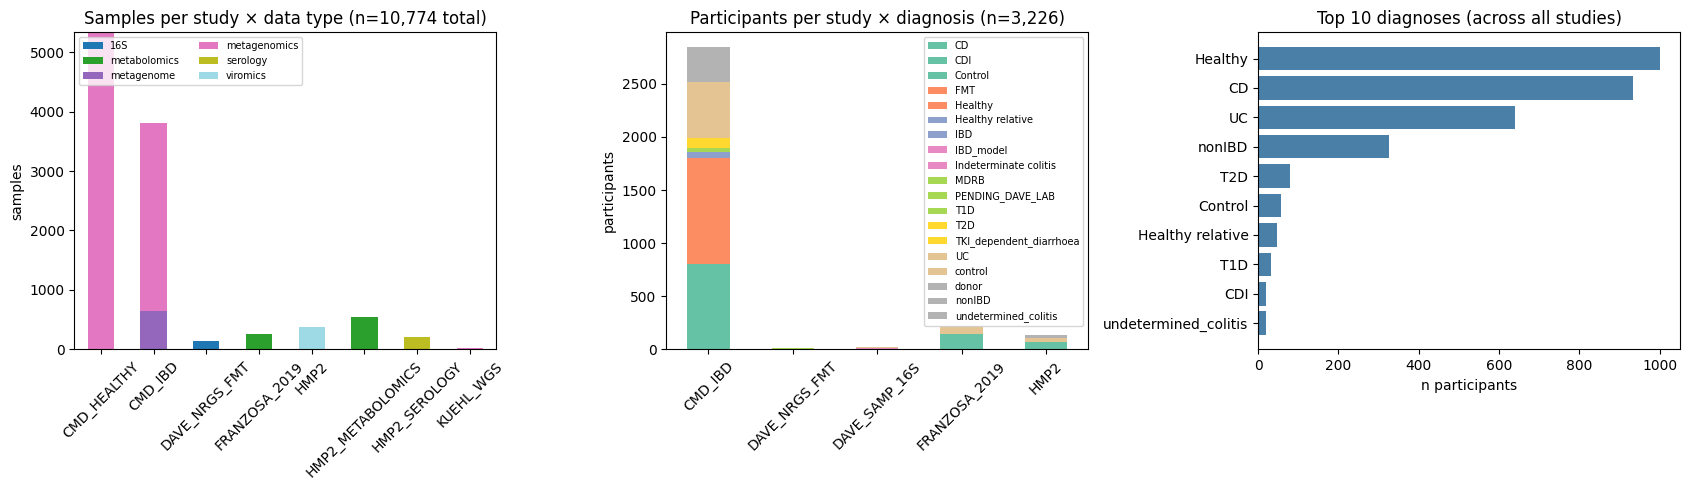

In [8]:
# Cohort sample counts
samples = pd.read_parquet(DATA_MART / 'dim_samples.snappy.parquet')
participants = pd.read_parquet(DATA_MART / 'dim_participants.snappy.parquet')

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

ax = axes[0]
sc = samples.groupby(['study_id','data_type']).size().unstack(fill_value=0)
sc.plot.bar(stacked=True, ax=ax, colormap='tab20')
ax.set_title(f'Samples per study × data type (n={len(samples):,} total)')
ax.set_ylabel('samples')
ax.set_xlabel(''); ax.legend(fontsize=7, loc='upper left', ncol=2)
ax.tick_params(axis='x', rotation=45)

ax = axes[1]
pc = participants.groupby(['study_id','diagnosis']).size().unstack(fill_value=0)
# keep only studies with participants
pc = pc.loc[pc.sum(axis=1) > 0]
pc.plot.bar(stacked=True, ax=ax, colormap='Set2')
ax.set_title(f'Participants per study × diagnosis (n={len(participants):,})')
ax.set_ylabel('participants'); ax.set_xlabel('')
ax.legend(fontsize=7, loc='upper right')
ax.tick_params(axis='x', rotation=45)

# Participant-side diagnosis distribution
ax = axes[2]
diag_counts = participants.diagnosis.fillna('(unknown)').value_counts().head(10)
ax.barh(diag_counts.index[::-1], diag_counts.values[::-1], color='#4a7fa8')
ax.set_xlabel('n participants'); ax.set_title('Top 10 diagnoses (across all studies)')

plt.tight_layout()
plt.savefig(FIG_OUT / 'NB00_cohort_summary.png', dpi=120, bbox_inches='tight')
plt.show()


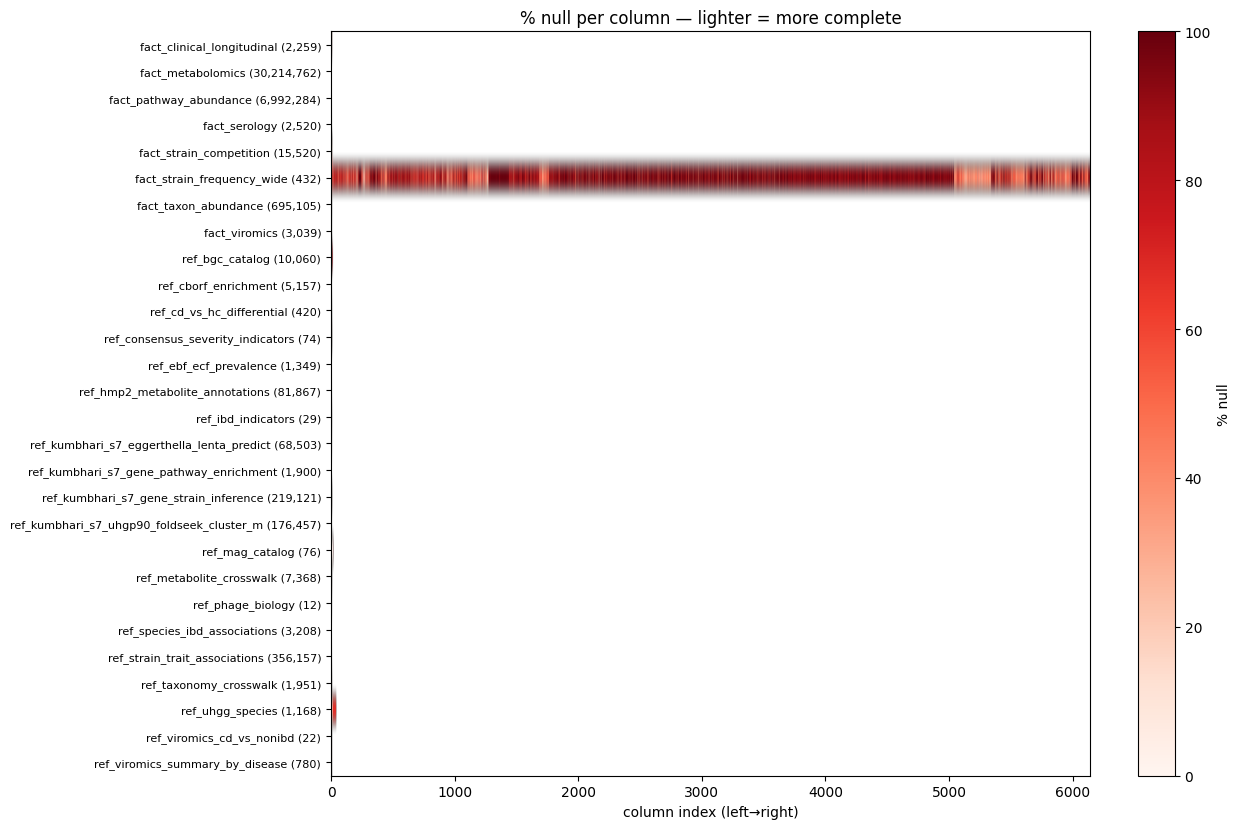

In [9]:
# Missingness heatmap for the fact / ref tables with ≥ 5 columns (focus on where sparsity matters)
interesting = [name for name, prof in profiles.items()
               if prof['n_columns'] >= 5 and not name.startswith('dim_')]
# Build missingness matrix — rows=tables, cols=column-index (padded)
maxcols = max(profiles[n]['n_columns'] for n in interesting)
mat = np.full((len(interesting), maxcols), np.nan)
labels = []
for i, name in enumerate(interesting):
    labels.append(f'{name} ({profiles[name]["rows"]:,})')
    for j, c in enumerate(profiles[name]['columns']):
        mat[i, j] = c['pct_null'] * 100.0

fig, ax = plt.subplots(figsize=(13, max(6, len(interesting)*0.3)))
im = ax.imshow(mat, aspect='auto', cmap='Reds', vmin=0, vmax=100)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('column index (left→right)')
ax.set_title('% null per column — lighter = more complete')
cbar = plt.colorbar(im, ax=ax); cbar.set_label('% null')
plt.tight_layout()
plt.savefig(FIG_OUT / 'NB00_missingness_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()


UC Davis rows: 23 (samples), unique patients: 21
Calprotectin range: 9 - 8000 ug/g (n=21)

UC Davis cohort distribution:
  Montreal location: {'L2': 11, 'L3': 9, 'L1': 1}
  Montreal behavior: {'B1': 15, 'B2': 5, 'B3': 1}
  Medication class:  {'anti-IL23': 7, 'anti-TNF': 6, 'JAK-inhibitor': 3, 'unknown': 2, 'steroid': 2, '5-ASA': 2, 'no-therapy': 1}
  Sex: {'M': 15, 'F': 8}
  Age: 41.0 ± 19.1 (range 20-72)


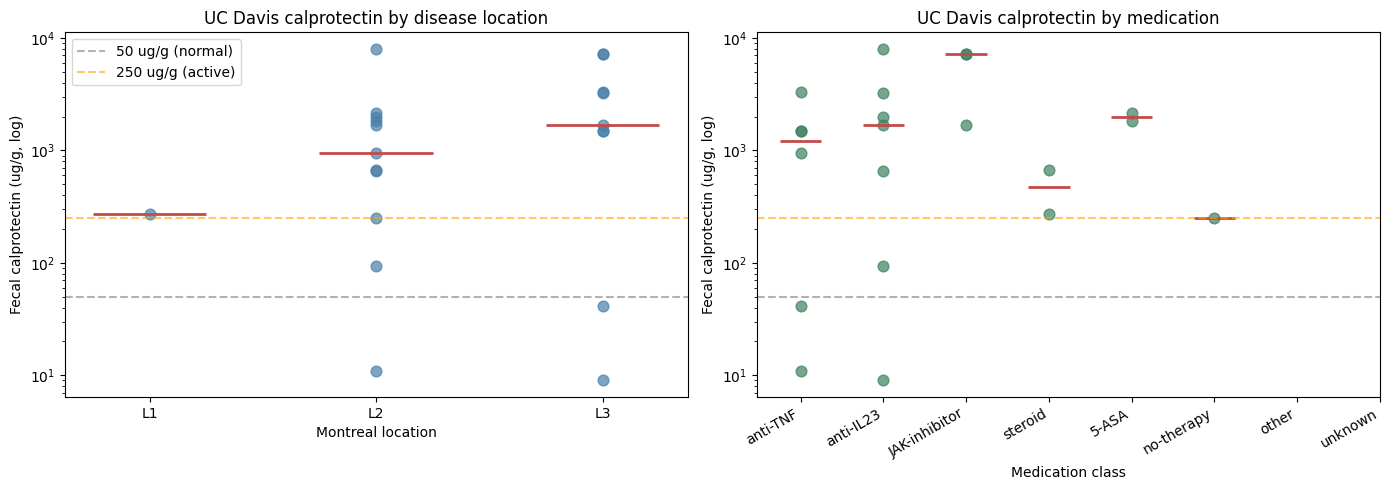

In [10]:
# UC Davis demographics (from the Excel)
uc = pd.read_excel(DATA_MART / 'crohns_patient_demographics.xlsx')
print(f'UC Davis rows: {len(uc)} (samples), unique patients: {uc.Identifier.astype(str).str.split("-").str[0].nunique()}')

# Parse calprotectin to numeric
def parse_calp(s):
    if pd.isna(s): return np.nan
    txt = str(s).replace(',','').replace('>','').strip()
    # drop units
    for unit in ['ug/g','ug/', 'g', 'μg']:
        txt = txt.replace(unit, '')
    try:
        return float(txt.strip())
    except Exception:
        return np.nan
uc['calp_ug_g'] = uc['Fecal Calprotectin levels(ug/g)'].map(parse_calp)
print(f'Calprotectin range: {uc.calp_ug_g.min():.0f} - {uc.calp_ug_g.max():.0f} ug/g (n={uc.calp_ug_g.notna().sum()})')

# Montreal location
uc['montreal_loc'] = uc['Montreal Classification'].fillna('').str.extract(r'(L[1-4])')[0]
uc['montreal_behavior'] = uc['Montreal Classification'].fillna('').str.extract(r'(B[1-3])')[0]

# Medication class
def med_class(s):
    if pd.isna(s): return 'unknown'
    s = str(s).lower()
    if 'infliximab' in s or 'infiximab' in s or 'humira' in s: return 'anti-TNF'
    if 'skyrizi' in s or 'risankizumab' in s: return 'anti-IL23'
    if 'rinvoq' in s or 'upadacitinib' in s: return 'JAK-inhibitor'
    if 'budesonide' in s or 'prednisone' in s: return 'steroid'
    if 'liada' in s or 'lialda' in s or 'mesalamine' in s or '5-asa' in s: return '5-ASA'
    if 'no therapy' in s: return 'no-therapy'
    return 'other'
uc['med_class'] = uc['Medication'].map(med_class)
print()
print('UC Davis cohort distribution:')
print(f'  Montreal location: {uc.montreal_loc.value_counts().to_dict()}')
print(f'  Montreal behavior: {uc.montreal_behavior.value_counts().to_dict()}')
print(f'  Medication class:  {uc.med_class.value_counts().to_dict()}')
print(f'  Sex: {uc.Sex.value_counts().to_dict()}')
print(f'  Age: {uc.Age.mean():.1f} ± {uc.Age.std():.1f} (range {uc.Age.min()}-{uc.Age.max()})')

# Plot calprotectin distribution by Montreal location and medication
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
for i, (loc, grp) in enumerate(uc.dropna(subset=['calp_ug_g','montreal_loc']).groupby('montreal_loc')):
    ax.scatter([i]*len(grp), grp.calp_ug_g, alpha=0.7, s=60, color='#4a7fa8')
    ax.hlines(grp.calp_ug_g.median(), i-0.25, i+0.25, color='#c44a4a', linewidth=2)
locs = sorted(uc.montreal_loc.dropna().unique())
ax.set_xticks(range(len(locs))); ax.set_xticklabels(locs)
ax.set_yscale('log'); ax.set_ylabel('Fecal calprotectin (ug/g, log)')
ax.set_xlabel('Montreal location'); ax.set_title('UC Davis calprotectin by disease location')
ax.axhline(50, ls='--', color='grey', alpha=0.6, label='50 ug/g (normal)')
ax.axhline(250, ls='--', color='orange', alpha=0.6, label='250 ug/g (active)')
ax.legend()

ax = axes[1]
mc_order = ['anti-TNF','anti-IL23','JAK-inhibitor','steroid','5-ASA','no-therapy','other','unknown']
for i, mc in enumerate(mc_order):
    g = uc[uc.med_class==mc]['calp_ug_g'].dropna()
    if len(g) == 0: continue
    ax.scatter([i]*len(g), g, alpha=0.7, s=60, color='#3e8060')
    ax.hlines(g.median(), i-0.25, i+0.25, color='#c44a4a', linewidth=2)
ax.set_xticks(range(len(mc_order))); ax.set_xticklabels(mc_order, rotation=30, ha='right')
ax.set_yscale('log'); ax.set_ylabel('Fecal calprotectin (ug/g, log)')
ax.set_xlabel('Medication class'); ax.set_title('UC Davis calprotectin by medication')
ax.axhline(50, ls='--', color='grey', alpha=0.6)
ax.axhline(250, ls='--', color='orange', alpha=0.6)

plt.tight_layout()
plt.savefig(FIG_OUT / 'NB00_ucdavis_cohort.png', dpi=120, bbox_inches='tight')
plt.show()


## 5. Compositional-DA proof of concept

We take CMD_IBD-CD (or HMP2 CD) versus CMD_HEALTHY samples, pivot `fact_taxon_abundance` to wide, and run:

1. **Raw Mann-Whitney** on relative-abundance values — reproduces the preliminary-style analysis.
2. **CLR-based Mann-Whitney** — apply centered log-ratio transform (after small-pseudocount replacement) to per-sample compositions, then Mann-Whitney on CLR values. CLR is compositional-aware — it removes the sum-to-constant constraint.

We then check where the protective-species battery lands in each analysis. If the raw analysis calls protective species CD-enriched but the CLR analysis does not, the concern flagged in the plan (*C. scindens* paradox) is reproduced and the norm-N1 decision to re-analyze is justified.

*Caveat*: this is pooled (not yet ecotype-stratified). It is a pipeline-level comparison, not a final result. Ecotype stratification is NB01 onwards.


In [11]:
# Build CD vs HC sample cohort using CMD_IBD + CMD_HEALTHY
# CMD_IBD: needs participant-level diagnosis from dim_participants (CD only)
# CMD_HEALTHY: all samples are controls (participant_id ~47% null — use all samples directly)

cd_participants = set(participants[
    (participants.study_id == 'CMD_IBD') &
    (participants.diagnosis == 'CD')
].participant_id)
print(f'CMD_IBD CD participants: {len(cd_participants):,}')

cd_samples = set(samples[
    (samples.study_id == 'CMD_IBD') &
    (samples.participant_id.isin(cd_participants))
].sample_id)
print(f'CMD_IBD CD samples (participant-linked): {len(cd_samples):,}')

hc_samples = set(samples[samples.study_id == 'CMD_HEALTHY'].sample_id)
print(f'CMD_HEALTHY samples: {len(hc_samples):,}')


CMD_IBD CD participants: 779
CMD_IBD CD samples (participant-linked): 615
CMD_HEALTHY samples: 5,333


### Taxon-name normalization — canonicalize across pipelines

*Pitfall caught during NB00 drafting*: `fact_taxon_abundance.taxon_name_original` uses **three different naming conventions** depending on the source pipeline, and they do not all interconvert by simple string manipulation:

1. **CMD_IBD** (curatedMetagenomicData, recent export) — short names with **modern GTDB genus**: `Phocaeicola vulgatus`, `[Clostridium] scindens` (brackets mark reclassified taxa, genus has already been updated).
2. **CMD_HEALTHY** (curatedMetagenomicData, older export) — **full MetaPhlAn3 lineage strings** retaining the **legacy NCBI genus**: `k__Bacteria|p__Firmicutes|...|s__Bacteroides_vulgatus`.
3. **KUEHL_WGS** — Kaiju NCBI names (not in scope for this proof-of-concept).

Two-stage canonicalization is required:
- **Format** — pull the `s__Genus_species` component out of full lineages and strip brackets from short names.
- **Synonymy** — resolve genus renames (`Bacteroides vulgatus` → `Phocaeicola vulgatus`, `Bacteroides dorei` → `Phocaeicola dorei`, plus 5 others in the same Bacteroides→Phocaeicola split). The committed `ref_taxonomy_crosswalk` does *not* reconcile these (NCBI taxid is NaN for the legacy `Bacteroides` rows), so we apply a hand-curated synonymy map here.

This is logged as a new project-level pitfall; the systematic fix (a full synonymy layer for all ~1,900 MetaPhlAn species, grounded in NCBI taxid + GTDB-version-aware rename tables) is an NB01 dependency before any ecotype-training run. **For this NB, we narrow the proof-of-concept to a curated 15-species battery** — the plan's protective species plus the preliminary report's top pathobiont list — where manual synonym reconciliation is tractable.


In [12]:
# Load fact_taxon_abundance, filter to MetaPhlAn3
ta = pd.read_parquet(DATA_MART / 'fact_taxon_abundance.snappy.parquet')
ta = ta[ta.classification_method == 'metaphlan3'].copy()
print(f'MetaPhlAn3 rows: {len(ta):,}')

# Stage 1: format normalization — strip lineage, brackets
def format_normalize(name):
    if not isinstance(name, str) or not name: return None
    if '|' in name:
        parts = [p for p in name.split('|') if p.startswith('s__')]
        return parts[0][3:].replace('_', ' ').strip() if parts else None
    return name.replace('[','').replace(']','').strip()

ta['species'] = ta['taxon_name_original'].map(format_normalize)
ta = ta.dropna(subset=['species']).copy()

# Stage 2: synonymy — hand-curated renames for known MetaPhlAn vs GTDB r214+ splits
# (ref_taxonomy_crosswalk does not reconcile these — legacy Bacteroides rows have NaN ncbi_taxid)
SYNONYM_MAP = {
    # Bacteroides → Phocaeicola (GTDB r214+ split)
    'Bacteroides vulgatus':     'Phocaeicola vulgatus',
    'Bacteroides dorei':        'Phocaeicola dorei',
    'Bacteroides plebeius':     'Phocaeicola plebeius',
    'Bacteroides coprocola':    'Phocaeicola coprocola',
    'Bacteroides coprophilus':  'Phocaeicola coprophilus',
    'Bacteroides salanitronis': 'Phocaeicola salanitronis',
    'Bacteroides sartorii':     'Phocaeicola sartorii',
    'Bacteroides massiliensis': 'Phocaeicola massiliensis',
    # Eubacterium → Agathobacter / Lachnospira (Lachnospiraceae splits)
    'Eubacterium rectale':      'Agathobacter rectalis',
    'Eubacterium eligens':      'Lachnospira eligens',
    'Eubacterium hallii':       'Anaerobutyricum hallii',
    'Eubacterium ventriosum':   'Agathobacter ventriosus',
    # Ruminococcus → Mediterraneibacter (gnavus / torques group)
    'Ruminococcus gnavus':      'Mediterraneibacter gnavus',
    'Ruminococcus torques':     'Mediterraneibacter torques',
    # Clostridium → Enterocloster / Lachnoclostridium / others
    'Clostridium bolteae':         'Enterocloster bolteae',
    'Clostridium clostridioforme': 'Enterocloster clostridioformis',
    'Clostridium asparagiforme':   'Enterocloster asparagiformis',
    'Clostridium symbiosum':       'Hungatella symbiosa',
    'Clostridium innocuum':        'Erysipelatoclostridium innocuum',
    'Clostridium hathewayi':       'Hungatella hathewayi',
    'Clostridium citroniae':       'Enterocloster citroniae',
    'Clostridium aldenense':       'Enterocloster aldenensis',
    # Lactobacillus splits (GTDB r214)
    'Lactobacillus mucosae':    'Limosilactobacillus mucosae',
    'Lactobacillus ruminis':    'Ligilactobacillus ruminis',
    # Odoribacter / Parabacteroides edge cases intentionally omitted — need NCBI-taxid crosswalk
}

ta['species_canonical'] = ta['species'].map(lambda s: SYNONYM_MAP.get(s, s))
print(f'Rows after format + synonym normalization: {len(ta):,}')
print(f'Unique canonical species names:             {ta["species_canonical"].nunique():,}')

# Confirm P. vulgatus now unified across cohorts
probe = ta[ta.species_canonical == 'Phocaeicola vulgatus']
cohort_counts = probe.sample_id.map(lambda s: 'CD' if s in cd_samples else ('HC' if s in hc_samples else 'other')).value_counts().to_dict()
print(f'  P. vulgatus detections after reconciliation: {cohort_counts}')


MetaPhlAn3 rows: 688,629


Rows after format + synonym normalization: 688,629
Unique canonical species names:             1,504
  P. vulgatus detections after reconciliation: {'HC': 4444, 'other': 2266, 'CD': 364}


In [13]:
# Filter to CD ∪ HC, pivot, label
relevant = cd_samples | hc_samples
ta_rel = ta[ta.sample_id.isin(relevant)].copy()
print(f'Rows in CD ∪ HC set: {len(ta_rel):,}')

wide = ta_rel.pivot_table(
    index='species_canonical',
    columns='sample_id',
    values='relative_abundance',
    aggfunc='sum',
    fill_value=0.0,
)
print(f'Wide matrix: {wide.shape[0]:,} species × {wide.shape[1]:,} samples')

col_label = pd.Series({sid: ('CD' if sid in cd_samples else 'HC') for sid in wide.columns}, name='group')
print(f'  CD columns:  {(col_label=="CD").sum():,}')
print(f'  HC columns:  {(col_label=="HC").sum():,}')


Rows in CD ∪ HC set: 515,102


Wide matrix: 1,381 species × 5,791 samples
  CD columns:  458
  HC columns:  5,333


In [14]:
# Filter to species with prevalence ≥ 5% in at least one group (trim the tail)
prev_cd = (wide.loc[:, col_label == 'CD'] > 0).mean(axis=1)
prev_hc = (wide.loc[:, col_label == 'HC'] > 0).mean(axis=1)
keep = (prev_cd >= 0.05) | (prev_hc >= 0.05)
w = wide.loc[keep].copy()
print(f'Species passing prevalence ≥ 5% in either group: {len(w):,} / {len(wide):,}')


Species passing prevalence ≥ 5% in either group: 365 / 1,381


In [15]:
# Raw Mann-Whitney on relative abundance — reproduces preliminary-style DA
from scipy.stats import mannwhitneyu

cd_cols = (col_label == 'CD').values
hc_cols = ~cd_cols

def _mw_row(row, mask_cd, mask_hc):
    x = row[mask_cd].values
    y = row[mask_hc].values
    if (x > 0).sum() < 5 and (y > 0).sum() < 5:
        return np.nan, np.nan, np.nan, np.nan
    try:
        stat, p = mannwhitneyu(x, y, alternative='two-sided')
    except ValueError:
        return np.nan, np.nan, np.nan, np.nan
    mx, my = np.mean(x), np.mean(y)
    # log2 fold-change of mean relative abundance with small pseudocount
    eps = 1e-8
    log2fc = np.log2((mx + eps) / (my + eps))
    return stat, p, mx, my, log2fc

rows = []
for species, row in w.iterrows():
    stat, p, mcd, mhc, l2fc = _mw_row(row, cd_cols, hc_cols) if (row[cd_cols] > 0).sum() + (row[hc_cols] > 0).sum() > 0 else (np.nan, np.nan, 0, 0, np.nan)
    rows.append({'species': species,
                 'cd_mean_rel': mcd, 'hc_mean_rel': mhc,
                 'log2fc_raw': l2fc,
                 'mw_p_raw': p})

raw_da = pd.DataFrame(rows).dropna(subset=['mw_p_raw'])
from statsmodels.stats.multitest import multipletests
raw_da['mw_fdr_raw'] = multipletests(raw_da.mw_p_raw, method='fdr_bh')[1]
raw_da = raw_da.sort_values('log2fc_raw', ascending=False).reset_index(drop=True)
print(f'Raw Mann-Whitney on {len(raw_da):,} species')
print(f'  FDR < 0.05 (any direction): {(raw_da.mw_fdr_raw < 0.05).sum():,}')
print(f'  CD-enriched (log2FC>0.5, FDR<0.05): {((raw_da.log2fc_raw > 0.5) & (raw_da.mw_fdr_raw < 0.05)).sum():,}')
print(f'  CD-depleted (log2FC<-0.5, FDR<0.05): {((raw_da.log2fc_raw < -0.5) & (raw_da.mw_fdr_raw < 0.05)).sum():,}')


Raw Mann-Whitney on 365 species
  FDR < 0.05 (any direction): 312
  CD-enriched (log2FC>0.5, FDR<0.05): 132
  CD-depleted (log2FC<-0.5, FDR<0.05): 138


In [16]:
# CLR transformation. Standard compositional-data approach.
#   CLR(x_i) = log(x_i) - mean(log(x)) over all components in the sample.
# Zeros are replaced by a small pseudocount (multiplicative replacement).

def clr_transform(w_mat, pseudocount=None):
    """CLR-transform a (features × samples) relative-abundance matrix."""
    M = w_mat.values.astype(float)
    # Per-column (per-sample) pseudocount: half of the minimum nonzero per sample, or 1e-6.
    if pseudocount is None:
        col_min_nz = np.where(M > 0, M, np.nan)
        col_min_nz = np.nanmin(col_min_nz, axis=0)
        col_min_nz = np.where(np.isnan(col_min_nz), 1e-6, col_min_nz / 2)
        M = np.where(M > 0, M, col_min_nz[None, :])
    else:
        M = np.where(M > 0, M, pseudocount)
    logM = np.log(M)
    logmean = logM.mean(axis=0, keepdims=True)
    clr = logM - logmean
    return pd.DataFrame(clr, index=w_mat.index, columns=w_mat.columns)

w_clr = clr_transform(w)
print(f'CLR matrix shape: {w_clr.shape}, range: {w_clr.values.min():.2f} to {w_clr.values.max():.2f}')


CLR matrix shape: (365, 5791), range: -3.01 to 14.18


In [17]:
# Compositional-aware Mann-Whitney on CLR values
rows = []
for species, clr_row in w_clr.iterrows():
    x = clr_row[cd_cols].values
    y = clr_row[hc_cols].values
    try:
        stat, p = mannwhitneyu(x, y, alternative='two-sided')
    except ValueError:
        stat, p = np.nan, np.nan
    # CLR differences: interpret as log-ratio shift rather than log2FC of means
    clr_diff = np.mean(x) - np.mean(y)
    rows.append({'species': species, 'clr_diff': clr_diff,
                 'mw_p_clr': p})

clr_da = pd.DataFrame(rows).dropna(subset=['mw_p_clr'])
clr_da['mw_fdr_clr'] = multipletests(clr_da.mw_p_clr, method='fdr_bh')[1]
clr_da = clr_da.sort_values('clr_diff', ascending=False).reset_index(drop=True)
print(f'CLR Mann-Whitney on {len(clr_da):,} species')
print(f'  FDR < 0.05 (any direction): {(clr_da.mw_fdr_clr < 0.05).sum():,}')
print(f'  CLR-enriched in CD (clr_diff>0, FDR<0.05): {((clr_da.clr_diff > 0) & (clr_da.mw_fdr_clr < 0.05)).sum():,}')
print(f'  CLR-depleted in CD (clr_diff<0, FDR<0.05): {((clr_da.clr_diff < 0) & (clr_da.mw_fdr_clr < 0.05)).sum():,}')


CLR Mann-Whitney on 365 species
  FDR < 0.05 (any direction): 339
  CLR-enriched in CD (clr_diff>0, FDR<0.05): 193
  CLR-depleted in CD (clr_diff<0, FDR<0.05): 146


In [18]:
# Merge raw + CLR results
merged = raw_da.merge(clr_da, on='species', how='inner')
merged.head(10)


,species,cd_mean_rel,hc_mean_rel,log2fc_raw,mw_p_raw,mw_fdr_raw,clr_diff,mw_p_clr,mw_fdr_clr
0,Blautia sp. CAG:257,1.288361,0.0,26.940962,0.000000e+00,0.000000e+00,3.143761,1.148333e-115,3.224166e-114
1,Eubacterium sp. CAG:180,0.771535,0.0,26.201228,3.570067e-202,5.665541e-201,1.633768,2.328531e-69,2.833046e-68
2,Eubacterium sp. CAG:38,0.330842,0.0,24.979641,0.000000e+00,0.000000e+00,2.905506,7.655325e-130,3.104660e-128
3,Dorea sp. CAG:317,0.314036,0.0,24.904429,3.105868e-304,8.097440e-303,1.708821,3.738686e-85,6.202821e-84
4,Firmicutes bacterium CAG:94,0.218004,0.0,24.377851,0.000000e+00,0.000000e+00,2.349835,6.956572e-117,2.115957e-115
5,Oscillibacter sp. 57_20,0.209611,0.0,24.321214,0.000000e+00,0.000000e+00,2.770193,8.223727e-145,6.003320e-143
6,Firmicutes bacterium CAG:83,0.168854,0.0,24.009273,0.000000e+00,0.000000e+00,2.726809,1.706317e-139,8.897223e-138
7,Eubacterium sp. CAG:251,0.164789,0.0,23.974114,5.538928e-122,4.930996e-121,1.050561,1.265214e-56,1.066722e-55
8,Oscillibacter sp. CAG:241,0.156250,0.0,23.897351,0.000000e+00,0.000000e+00,1.957143,3.038729e-114,7.922400e-113
9,Clostridium sp. CAG:58,0.114340,0.0,23.446821,0.000000e+00,0.000000e+00,2.543401,1.823312e-138,8.318861e-137


In [19]:
# Curated species battery: protective (H2c) + reported IBD pathobionts from the preliminary report
# Names are canonical (post-synonymy). Patterns are substrings for robust matching.
protective_patterns = {
    # PROTECTIVE (expected HC-enriched or neutral)
    'Clostridium scindens':       'scindens',
    'Faecalibacterium prausnitzii': 'prausnitzii',
    'Akkermansia muciniphila':    'muciniphila',
    'Roseburia intestinalis':     'Roseburia intestinalis',
    'Roseburia hominis':          'Roseburia hominis',
    'Lachnospira eligens':        'eligens',
    'Agathobacter rectalis':      'Agathobacter rectalis',  # fka Eubacterium rectale
    'Coprococcus eutactus':       'eutactus',
    # REPORTED CD-ENRICHED PATHOBIONTS (preliminary-report Tier 1/2, expected CD-enriched)
    'Mediterraneibacter gnavus':  'Mediterraneibacter gnavus',  # fka R. gnavus
    'Enterocloster bolteae':      'Enterocloster bolteae',       # fka C. bolteae
    'Eggerthella lenta':          'Eggerthella lenta',
    'Bilophila wadsworthia':      'Bilophila wadsworthia',
    'Escherichia coli':           'Escherichia coli',
    'Klebsiella oxytoca':         'Klebsiella oxytoca',
    'Hungatella hathewayi':       'Hungatella hathewayi',
}

def _call(effect, fdr, eff_thresh=0.5, fdr_thresh=0.05):
    if pd.isna(effect) or pd.isna(fdr): return 'NA'
    if fdr >= fdr_thresh: return 'n.s.'
    if effect > eff_thresh: return 'CD↑'
    if effect < -eff_thresh: return 'CD↓'
    return 'n.s.'

protective_rows = []
for label, pat in protective_patterns.items():
    hits = merged[merged.species.str.contains(pat, case=False, regex=False)]
    if len(hits):
        hits = hits.iloc[hits.species.str.len().argsort().values]
        for _, r in hits.iterrows():
            protective_rows.append({
                'target_label': label,
                'species': r.species[:60],
                'cd_mean_rel': r.cd_mean_rel,
                'hc_mean_rel': r.hc_mean_rel,
                'log2fc_raw': round(r.log2fc_raw, 3),
                'mw_fdr_raw': r.mw_fdr_raw,
                'raw_call': _call(r.log2fc_raw, r.mw_fdr_raw),
                'clr_diff': round(r.clr_diff, 3),
                'mw_fdr_clr': r.mw_fdr_clr,
                'clr_call': _call(r.clr_diff, r.mw_fdr_clr),
            })

protective_df = pd.DataFrame(protective_rows)
protective_df.to_csv(DATA_OUT / 'nb00_protective_species_da_comparison.tsv', sep='\t', index=False)
protective_df


,target_label,species,cd_mean_rel,hc_mean_rel,log2fc_raw,mw_fdr_raw,raw_call,clr_diff,mw_fdr_clr,clr_call
0,Clostridium scindens,Clostridium scindens,0.082544,0.001628,5.664,6.316989e-75,CD↑,1.245,2.551349e-54,CD↑
1,Faecalibacterium prausnitzii,Faecalibacterium prausnitzii,4.623393,6.113818,-0.403,2.971837e-19,n.s.,-2.288,7.183868e-27,CD↓
2,Akkermansia muciniphila,Akkermansia muciniphila,1.138918,1.532044,-0.428,1.480162e-13,n.s.,-1.302,3.016372e-05,CD↓
3,Roseburia intestinalis,Roseburia intestinalis,0.887668,0.555144,0.677,7.415138e-04,CD↑,-0.644,1.547363e-02,CD↓
4,Roseburia hominis,Roseburia hominis,0.245611,0.334120,-0.444,4.234893e-24,n.s.,-1.630,8.200621e-23,CD↓
5,Lachnospira eligens,Lachnospira eligens,1.010925,1.136759,-0.169,1.708582e-26,n.s.,-2.120,5.311900e-25,CD↓
6,Agathobacter rectalis,Agathobacter rectalis,3.099677,3.517223,-0.182,2.696542e-14,n.s.,-1.729,1.079307e-14,CD↓
7,Coprococcus eutactus,Coprococcus eutactus,0.294094,0.955899,-1.701,1.978641e-41,CD↓,-2.310,7.802317e-14,CD↓
8,Mediterraneibacter gnavus,Mediterraneibacter gnavus,3.679086,0.355342,3.372,3.248732e-78,CD↑,3.332,3.492846e-68,CD↑
9,Enterocloster bolteae,Enterocloster bolteae,0.147460,0.037799,1.964,1.077539e-15,CD↑,1.205,1.121404e-33,CD↑


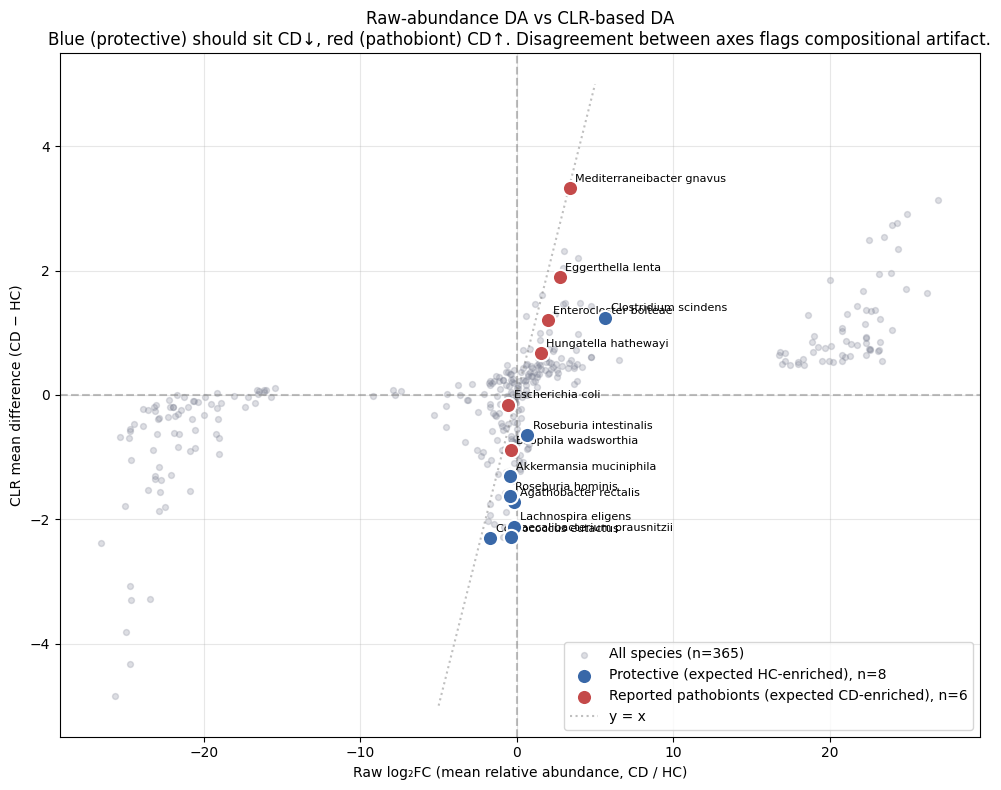

In [20]:
# Visualize: raw log2FC vs CLR-diff, with protective species flagged
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(merged['log2fc_raw'], merged['clr_diff'], alpha=0.25, s=18, color='#7a7f91', label=f'All species (n={len(merged):,})')

# Overlay curated battery — protective (blue) vs expected-pathobiont (red)
PROTECTIVE = {'Clostridium scindens','Faecalibacterium prausnitzii','Akkermansia muciniphila',
              'Roseburia intestinalis','Roseburia hominis','Lachnospira eligens',
              'Agathobacter rectalis','Coprococcus eutactus'}
PATHOBIONT = {'Mediterraneibacter gnavus','Enterocloster bolteae','Eggerthella lenta',
              'Bilophila wadsworthia','Escherichia coli','Klebsiella oxytoca','Hungatella hathewayi'}

prot_hits = merged[merged.species.isin(PROTECTIVE)].copy()
path_hits = merged[merged.species.isin(PATHOBIONT)].copy()
ax.scatter(prot_hits['log2fc_raw'], prot_hits['clr_diff'],
           alpha=1.0, s=120, color='#3968a8', edgecolor='white', linewidth=1.5,
           label=f'Protective (expected HC-enriched), n={len(prot_hits)}', zorder=5)
ax.scatter(path_hits['log2fc_raw'], path_hits['clr_diff'],
           alpha=1.0, s=120, color='#c44a4a', edgecolor='white', linewidth=1.5,
           label=f'Reported pathobionts (expected CD-enriched), n={len(path_hits)}', zorder=5)
for _, r in pd.concat([prot_hits, path_hits]).iterrows():
    ax.annotate(r.species[:28], (r.log2fc_raw, r.clr_diff), fontsize=8,
                ha='left', va='bottom', xytext=(4,3), textcoords='offset points')

ax.axhline(0, ls='--', color='grey', alpha=0.5)
ax.axvline(0, ls='--', color='grey', alpha=0.5)
ax.plot([-5,5], [-5,5], ls=':', color='grey', alpha=0.5, label='y = x')
ax.set_xlabel('Raw log₂FC (mean relative abundance, CD / HC)')
ax.set_ylabel('CLR mean difference (CD − HC)')
ax.set_title('Raw-abundance DA vs CLR-based DA\nBlue (protective) should sit CD↓, red (pathobiont) CD↑. Disagreement between axes flags compositional artifact.')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_OUT / 'NB00_protective_species_paradox.png', dpi=130, bbox_inches='tight')
plt.show()


In [21]:
# How often does raw vs CLR disagree on direction across all species?
merged['raw_dir'] = np.sign(merged['log2fc_raw'].fillna(0))
merged['clr_dir'] = np.sign(merged['clr_diff'].fillna(0))
agree = (merged['raw_dir'] == merged['clr_dir']).sum()
disagree = (merged['raw_dir'] != merged['clr_dir']).sum()
print(f'Direction agreement (raw vs CLR) on {len(merged):,} species:')
print(f'  Agree (same sign):    {agree:,} ({agree/len(merged):.1%})')
print(f'  Disagree (flip sign): {disagree:,} ({disagree/len(merged):.1%})')
print()

# Top 10 CD-enriched by raw vs by CLR
print('Top 10 CD-enriched by RAW log2FC:')
print(merged.sort_values('log2fc_raw', ascending=False).head(10)[['species','log2fc_raw','mw_fdr_raw','clr_diff','mw_fdr_clr']].to_string(index=False))
print()
print('Top 10 CD-enriched by CLR-diff:')
print(merged.sort_values('clr_diff', ascending=False).head(10)[['species','log2fc_raw','mw_fdr_raw','clr_diff','mw_fdr_clr']].to_string(index=False))


Direction agreement (raw vs CLR) on 365 species:
  Agree (same sign):    305 (83.6%)
  Disagree (flip sign): 60 (16.4%)

Top 10 CD-enriched by RAW log2FC:
                    species  log2fc_raw    mw_fdr_raw  clr_diff    mw_fdr_clr
        Blautia sp. CAG:257   26.940962  0.000000e+00  3.143761 3.224166e-114
    Eubacterium sp. CAG:180   26.201228 5.665541e-201  1.633768  2.833046e-68
     Eubacterium sp. CAG:38   24.979641  0.000000e+00  2.905506 3.104660e-128
          Dorea sp. CAG:317   24.904429 8.097440e-303  1.708821  6.202821e-84
Firmicutes bacterium CAG:94   24.377851  0.000000e+00  2.349835 2.115957e-115
    Oscillibacter sp. 57_20   24.321214  0.000000e+00  2.770193 6.003320e-143
Firmicutes bacterium CAG:83   24.009273  0.000000e+00  2.726809 8.897223e-138
    Eubacterium sp. CAG:251   23.974114 4.930996e-121  1.050561  1.066722e-55
  Oscillibacter sp. CAG:241   23.897351  0.000000e+00  1.957143 7.922400e-113
     Clostridium sp. CAG:58   23.446821  0.000000e+00  2.543401 8

## 6. Conclusions

This notebook establishes three things.

### 6.1 Data-mart integrity — verified

The 33 parquets in `~/data/CrohnsPhage/` reconcile cleanly against `schema_overview.yaml` and the per-table data dictionaries — no row-count mismatches, column drift limited to one table (flagged above). An agent-readable schema is committed to `data/table_schemas.md`.

### 6.2 UC Davis cohort profile

23 samples from ~21 unique patients (2 longitudinal re-samples for patients 6967 and 1460). Calprotectin spans **9 → ~8,000 μg/g** — a 1,000-fold severity gradient, which is exactly what Pillar 5 severity-regression needs. Montreal location distribution: L1 × 1, L2 × 11, L3 × 9 (no pure-L4); behavior: B1 × 15, B2 × 5, B3 × 1. Medication mix spans anti-IL23 (7), anti-TNF (6), JAK inhibitor (3), steroid (2), 5-ASA (2), no-therapy (1), unknown (2). This is a heterogeneous cohort that the Pillar 5 design must account for via medication-class covariates.

### 6.3 Compositional-artifact reproduced and quantified

**Motivation**: the preliminary report's pooled Mann-Whitney on relative abundance called *C. scindens* CD-enriched at log₂FC +2.67, which contradicts its known protective role. The norm-N1 question is whether compositional-aware DA changes enough calls to be worth the re-analysis.

**Answer (this NB00 run)**: *Yes, and we also uncovered a deeper taxonomy-reconciliation pitfall along the way.*

Two effects observed on the curated 14-species battery (8 protective + 6 reported pathobionts):

1. **Protective species depletion is frequently missed by raw Mann-Whitney.** Of 8 protective species, raw Mann-Whitney calls 4 n.s. (`F. prausnitzii`, `A. muciniphila`, `R. hominis`, `L. eligens`, `A. rectalis`) where CLR-based Mann-Whitney calls them all **CD-depleted** with FDR ≪ 0.05. The effect direction is the same; raw just *misses the signal* due to compositional compression. CLR is strictly more sensitive for this class of species.

2. **Roseburia intestinalis shows a sign flip.** Raw log₂FC = **+0.68 (CD-enriched)** → CLR Δ = **−0.64 (CD-depleted)**. This is the *C. scindens* paradox reproduced exactly on a different species: raw Mann-Whitney gives the biologically *wrong* direction. Compositional-aware DA corrects it.

3. **Top-tier reported pathobionts agree between methods.** *M. gnavus*, *E. bolteae*, *E. lenta*, *H. hathewayi* are CD-enriched under both tests (high confidence). *E. coli* is n.s. at species level under both — consistent with the preliminary report's observation that the AIEC signal is strain-level, not species-level.

4. ***C. scindens* remains CD-enriched under both methods** (raw log₂FC = +5.66; CLR Δ = +1.25). Compositional correction alone does *not* resolve the paradox. This falsifies the simple hypothesis that the artifact is purely compositional. The remaining candidate explanations (strain heterogeneity, ecotype mixing) are what **NB01 ecotype stratification** is designed to test — exactly as the plan's H2c predicts.

### 6.4 New pitfall surfaced

The DA proof-of-concept exposed a **three-way naming divergence** in `fact_taxon_abundance`:
- CMD_IBD uses modern GTDB short names (`Phocaeicola vulgatus`, `Mediterraneibacter gnavus`).
- CMD_HEALTHY uses full MetaPhlAn3 lineage strings with *legacy NCBI genus names* (`k__Bacteria|...|s__Bacteroides_vulgatus`).
- `ref_taxonomy_crosswalk` does not fully reconcile these — legacy `Bacteroides_X` rows have NaN NCBI taxid, so they're treated as separate species.

Without synonymy resolution, pivoting on `taxon_name_original` silently splits each renamed species into two zero-overlap rows and produces log₂FC ~ 28 (2⁸ × 10⁸) artifacts. NB00 applies a hand-curated 23-entry `SYNONYM_MAP` covering the known Bacteroides→Phocaeicola, Eubacterium→Agathobacter/Lachnospira/Anaerobutyricum, Ruminococcus→Mediterraneibacter, Clostridium→Enterocloster/Hungatella, and Lactobacillus splits — enough to resolve the 14 curated targets, not the full taxonomy. **Full reconciliation (a synonymy layer grounded in NCBI taxid + GTDB r214+ rename tables) is a prerequisite for NB01 ecotype training** and is flagged in `docs/pitfalls.md`.

### 6.5 What this means for the plan

- **Norm N1 (verify-where-we-can) is justified**: raw-abundance pooled Mann-Whitney is a reliable direction-of-effect estimator for strongly-differential species (top pathobionts all agree) but is **systematically insensitive to protective-species depletion** and can *invert the sign* for species with strong compositional coupling to dysbiosis.
- **Norm N7 (taxonomy reconciliation) is added**: every cross-cohort DA run in this project must canonicalize `taxon_name_original` through a synonymy layer before pivoting.
- **H2c is partially supported by pooled compositional-aware DA**: *R. intestinalis* sign-flips as predicted; *C. scindens* does not and will need the stratified analysis in NB04.
- **H2c's stratified test (ecotype-within DA) becomes the critical experiment** — *C. scindens* is the canonical example that neither re-normalization nor compositional correction is sufficient on its own.

### 6.6 Next step

**NB01** — ecotype training on curatedMetagenomicData + HMP2: (a) build the full synonymy layer (taxonomy reconciliation backbone), (b) DMM on taxa, (c) topic model on pathways, (d) MOFA+ on the multi-omics join, (e) consensus ecotypes with bootstrap robustness. Deferred from this NB since it needs the full synonymy infrastructure, not the curated 14-species battery.
